### 1. Importar librerías y cargar datos

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

project_root = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()
data_path = project_root / "data" / "wdbc_clean.csv"
outputs_tables = project_root / "outputs" / "tables"
outputs_figures = project_root / "outputs" / "figures"

outputs_tables.mkdir(parents=True, exist_ok=True)
outputs_figures.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(data_path)

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


### 2. Dimensiones y tipos de datos

In [2]:
print("Dimensiones del dataset:")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\nTipos de datos:")
df.info()

Dimensiones del dataset:
Filas: 569
Columnas: 32

Tipos de datos:
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    str    
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave_points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               

### 3. Comprobar nulos y duplicados

In [3]:
print("Valores nulos totales:", df.isnull().sum().sum())
print("Filas duplicadas:", df.duplicated().sum())

Valores nulos totales: 0
Filas duplicadas: 0


### 4. Distribución de clases

In [4]:
class_counts = df["diagnosis"].value_counts()
class_percentages = df["diagnosis"].value_counts(normalize=True) * 100

class_summary = pd.DataFrame({
    "n": class_counts,
    "porcentaje": class_percentages.round(2)
})

class_summary

,n,porcentaje
diagnosis,,
B,357,62.74
M,212,37.26


### 5. Gráfico de clases

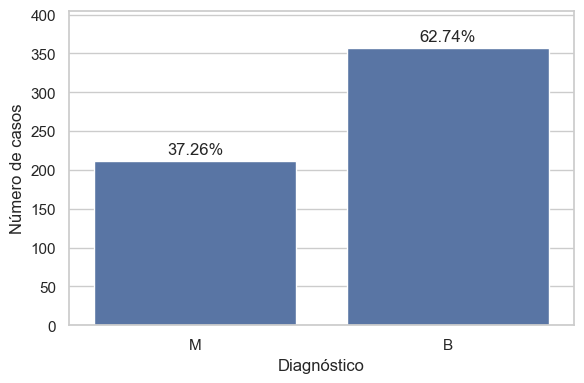

In [15]:
plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x="diagnosis")

plt.xlabel("Diagnóstico")
plt.ylabel("Número de casos")

total = len(df)

for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total

    ax.text(
        p.get_x() + p.get_width() / 2,
        count + 5,
        f"{percentage:.2f}%",
        ha="center",
        va="bottom"
    )

plt.ylim(0, ax.get_ylim()[1] + 30)

plt.tight_layout()
plt.savefig(outputs_figures / "distribucion_clases.png", dpi=300)
plt.show()

### 6. Estadística descriptiva.

In [6]:
df.drop(columns=["id"]).describe().T

,count,mean,std,min,25%,50%,75%,max
radius_mean,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture_mean,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter_mean,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area_mean,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness_mean,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness_mean,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity_mean,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points_mean,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry_mean,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension_mean,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


### 7. Separar variables numéricas

In [7]:
feature_cols = df.drop(columns=["id", "diagnosis"]).columns.tolist()

print(f"Número de variables predictoras: {len(feature_cols)}")
feature_cols

Número de variables predictoras: 30


['radius_mean',
 'texture_mean',
 'perimeter_mean',
 'area_mean',
 'smoothness_mean',
 'compactness_mean',
 'concavity_mean',
 'concave_points_mean',
 'symmetry_mean',
 'fractal_dimension_mean',
 'radius_se',
 'texture_se',
 'perimeter_se',
 'area_se',
 'smoothness_se',
 'compactness_se',
 'concavity_se',
 'concave_points_se',
 'symmetry_se',
 'fractal_dimension_se',
 'radius_worst',
 'texture_worst',
 'perimeter_worst',
 'area_worst',
 'smoothness_worst',
 'compactness_worst',
 'concavity_worst',
 'concave_points_worst',
 'symmetry_worst',
 'fractal_dimension_worst']

### 8. Matriz de correlación

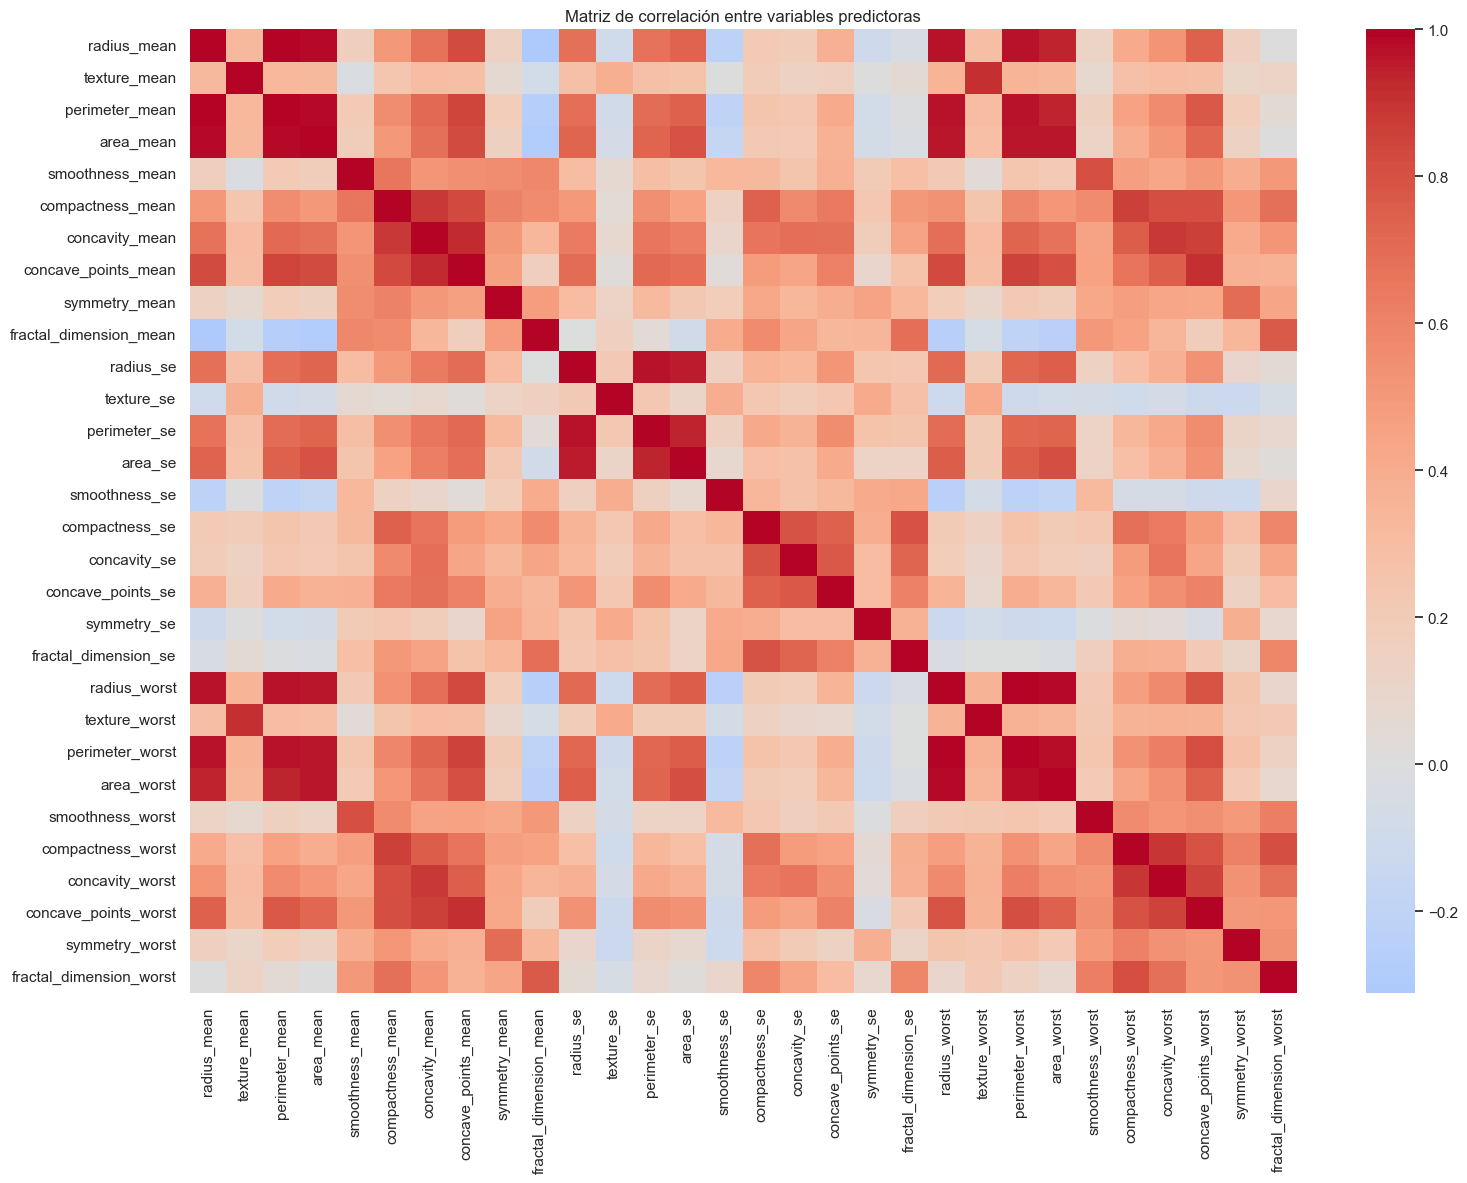

In [8]:
plt.figure(figsize=(16, 12))
corr = df[feature_cols].corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables predictoras")
plt.tight_layout()
plt.savefig(outputs_figures / "matriz_correlacion.png", dpi=300)
plt.show()

### 9. Variables más correlacionadas con el diagnóstico

In [9]:
df_corr = df.copy()
df_corr["diagnosis_binary"] = df_corr["diagnosis"].map({"B": 0, "M": 1})

target_corr = (
    df_corr[feature_cols + ["diagnosis_binary"]]
    .corr()["diagnosis_binary"]
    .drop("diagnosis_binary")
    .sort_values(ascending=False)
)

target_corr.head(10)

concave_points_worst    0.793566
perimeter_worst         0.782914
concave_points_mean     0.776614
radius_worst            0.776454
perimeter_mean          0.742636
area_worst              0.733825
radius_mean             0.730029
area_mean               0.708984
concavity_mean          0.696360
concavity_worst         0.659610
Name: diagnosis_binary, dtype: float64

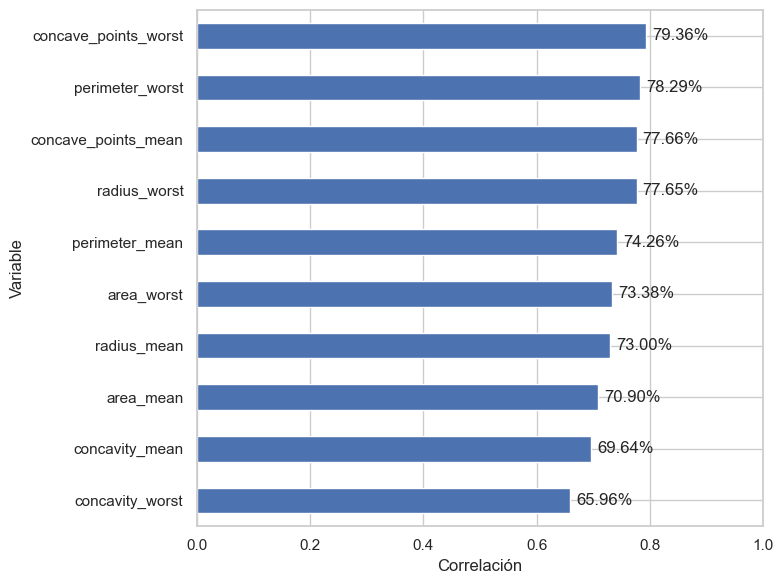

In [17]:
plt.figure(figsize=(8, 6))
ax = target_corr.head(10).sort_values().plot(kind="barh")
plt.xlabel("Correlación")
plt.ylabel("Variable")
plt.xlim(0, 1)

for i, value in enumerate(target_corr.head(10).sort_values()):
    ax.text(
        value + 0.01,
        i,
        f"{value * 100:.2f}%",
        va="center"
    )

plt.tight_layout()
plt.savefig(outputs_figures / "top10_correlaciones_diagnostico.png", dpi=300)
plt.show()

### 10. Comparación de algunas variables por clase

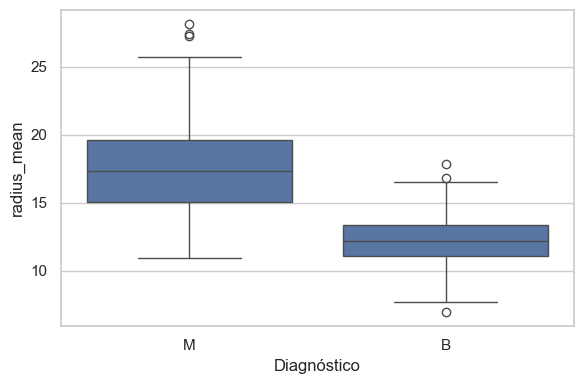

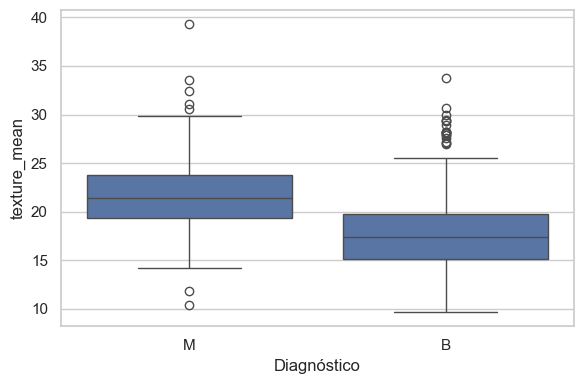

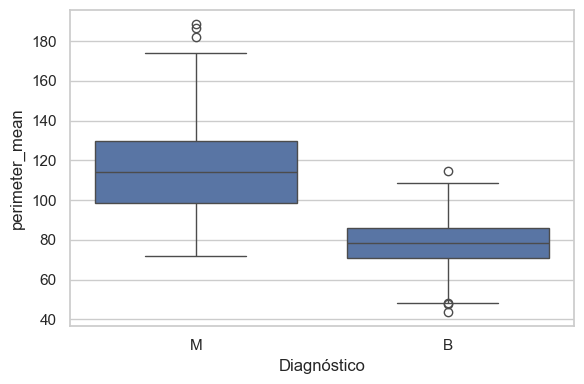

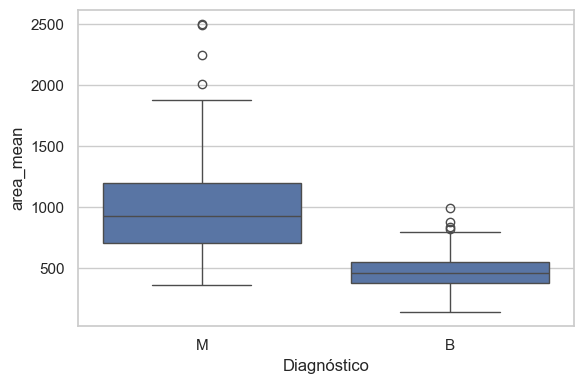

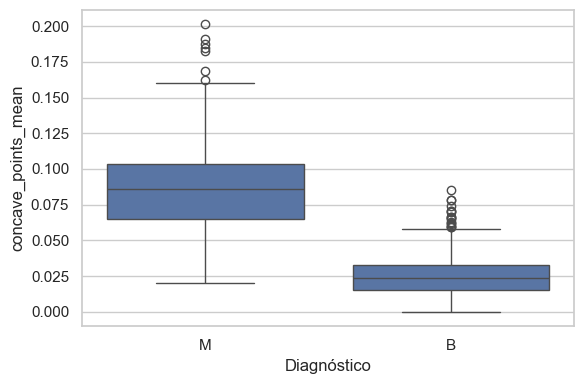

In [16]:
selected_features = [
    "radius_mean",
    "texture_mean",
    "perimeter_mean",
    "area_mean",
    "concave_points_mean"
]

for col in selected_features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df, x="diagnosis", y=col)
    plt.xlabel("Diagnóstico")
    plt.ylabel(col)
    plt.tight_layout()
    plt.savefig(outputs_figures / f"boxplot_{col}.png", dpi=300)
    plt.show()

### Guardar resultados:

In [12]:
outputs_tables = project_root / "outputs" / "tables"
outputs_figures = project_root / "outputs" / "figures"

outputs_tables.mkdir(parents=True, exist_ok=True)
outputs_figures.mkdir(parents=True, exist_ok=True)

class_summary.to_csv(outputs_tables / "class_distribution.csv")
target_corr.to_csv(outputs_tables / "target_correlations.csv")

print("Tablas guardadas correctamente.")

Tablas guardadas correctamente.
